In [1]:
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

### Understand the Dataset

In [2]:
df = pd.read_csv(r"C:\Users\paula\Downloads\creditcard.csv\creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [4]:
df.duplicated().sum()

np.int64(1081)

In [5]:
df.isna().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [6]:
# remove duplicates
df = df.drop_duplicates(keep='first').reset_index(drop=True)

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df['Class'].value_counts()

Class
0    283253
1       473
Name: count, dtype: int64

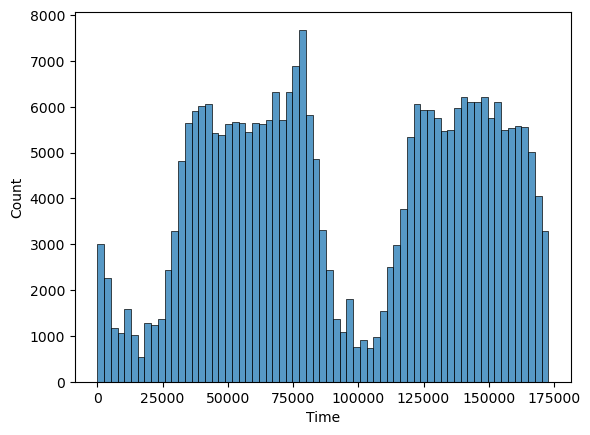

In [9]:
sns.histplot(df['Time'])
plt.show()

### data preprocessing

In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df['Amount'] = scaler.fit_transform(df[['Amount']])
df['Time'] = scaler.fit_transform(df[['Time']])

In [11]:
import joblib

# Save the scaler AFTER you fit it on Amount
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

In [12]:
x = df.drop('Class', axis=1)
y = df['Class']

In [13]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, stratify=y, shuffle=True, random_state=42)

### ANN

In [14]:
model = Sequential([
    Dense(64, activation='relu', input_dim=x_train.shape[1]), # hidden layer and input layer
    Dropout(0.3),
    Dense(32, activation='relu'),                             # hidden layer
    Dropout(0.3),
    Dense(16, activation='relu'),                             # hidden layer
    Dropout(0.3),
    Dense(1, activation='sigmoid')                            # output layer
])

c:\Users\paula\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [15]:
import tensorflow as tf

# 1. Configure the Focal Loss function
focal_loss = tf.keras.losses.BinaryFocalCrossentropy(
    gamma=2.0,  # Forces the model to focus on the hard-to-predict minority class
    alpha=0.25  # Acts as a weight to balance the importance of Class 0 vs Class 1
)

# 2. Swap 'accuracy' for metrics that actually measure minority detection
evaluation_metrics = [
    tf.keras.metrics.Precision(name='precision'),
    tf.keras.metrics.Recall(name='recall'),
    tf.keras.metrics.AUC(curve='PR', name='pr_auc') # Precision-Recall Area Under Curve
]

# 3. Compile the model
model.compile(
    optimizer='adam',
    loss=focal_loss,
    metrics=evaluation_metrics
)

In [16]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss',patience=2,restore_best_weights=True)

In [17]:
history = model.fit(x_train, y_train, epochs=50, batch_size=32, validation_split=0.2, callbacks=[early_stop])

Epoch 1/50
5675/5675 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step - loss: 0.0040 - pr_auc: 0.3764 - precision: 0.4924 - recall: 0.4300 - val_loss: 0.0012 - val_pr_auc: 0.8114 - val_precision: 0.8846 - val_recall: 0.5897
Epoch 2/50
5675/5675 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - loss: 0.0017 - pr_auc: 0.6420 - precision: 0.8012 - recall: 0.4433 - val_loss: 0.0012 - val_pr_auc: 0.8201 - val_precision: 0.9138 - val_recall: 0.6795
Epoch 3/50
5675/5675 ━━━━━━━━━━━━━━━━━━━━ 11s 1ms/step - loss: 0.0014 - pr_auc: 0.7133 - precision: 0.8632 - recall: 0.5467 - val_loss: 0.0012 - val_pr_auc: 0.8356 - val_precision: 0.8784 - val_recall: 0.8333
Epoch 4/50
5675/5675 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - loss: 0.0012 - pr_auc: 0.7231 - precision: 0.8629 - recall: 0.5667 - val_loss: 0.0011 - val_pr_auc: 0.8453 - val_precision: 0.8571 - val_recall: 0.8462
Epoch 5/50
5675/5675 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - loss: 0.0012 - pr_auc: 0.7603 - precision: 0.8879 - recall: 0.6333 - val_loss: 8.4367e-04 - val_pr_auc: 0.8522 

In [18]:
y_pred = model.predict(x_test)

1774/1774 ━━━━━━━━━━━━━━━━━━━━ 1s 458us/step


In [19]:
y_pred = (y_pred > 0.5)

In [20]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[56643     8]
 [   27    68]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.89      0.72      0.80        95

    accuracy                           1.00     56746
   macro avg       0.95      0.86      0.90     56746
weighted avg       1.00      1.00      1.00     56746



1774/1774 ━━━━━━━━━━━━━━━━━━━━ 1s 463us/step


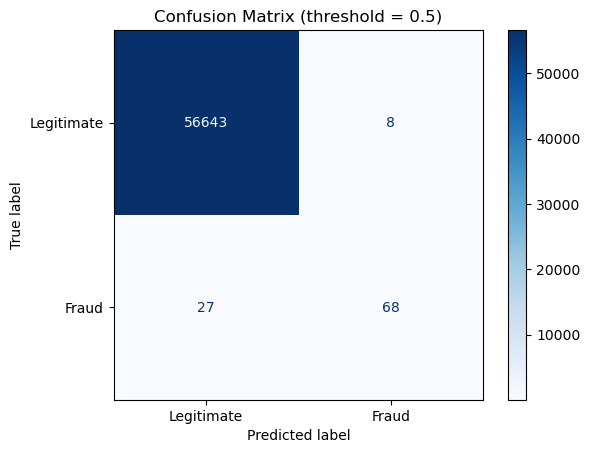

              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56651
       Fraud       0.89      0.72      0.80        95

    accuracy                           1.00     56746
   macro avg       0.95      0.86      0.90     56746
weighted avg       1.00      1.00      1.00     56746



In [21]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Get raw probabilities (not binary yet)
y_prob = model.predict(x_test).flatten()

# Confusion matrix at 0.5
y_pred = (y_prob > 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Legitimate", "Fraud"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix (threshold = 0.5)")
plt.show()

print(classification_report(y_test, y_pred, target_names=["Legitimate", "Fraud"]))

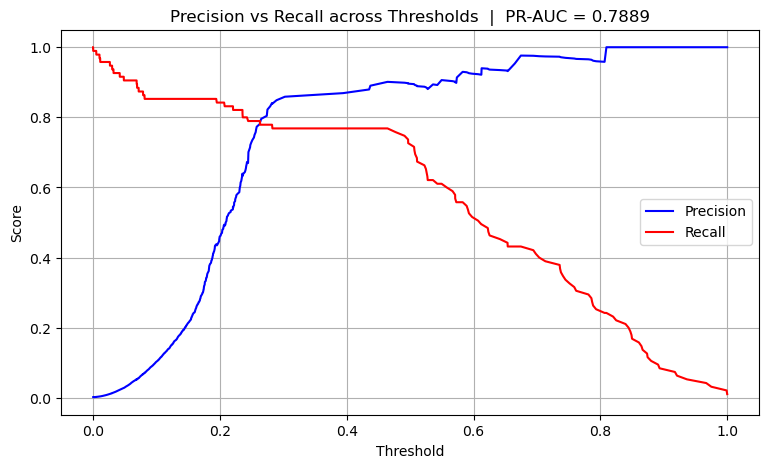

In [22]:
from sklearn.metrics import precision_recall_curve, auc
import numpy as np

precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob)
pr_auc = auc(recalls, precisions)

# Plot the curve
plt.figure(figsize=(9, 5))
plt.plot(thresholds, precisions[:-1], label="Precision", color="blue")
plt.plot(thresholds, recalls[:-1], label="Recall", color="red")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title(f"Precision vs Recall across Thresholds  |  PR-AUC = {pr_auc:.4f}")
plt.legend()
plt.grid(True)
plt.show()

In [23]:
# F1 score at each threshold
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-8)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"Best threshold:  {best_threshold:.4f}")
print(f"Precision:       {precisions[best_idx]:.4f}")
print(f"Recall:          {recalls[best_idx]:.4f}")
print(f"F1 Score:        {f1_scores[best_idx]:.4f}")
print(f"PR-AUC:          {pr_auc:.4f}")

Best threshold:  0.4642
Precision:       0.9012
Recall:          0.7684
F1 Score:        0.8295
PR-AUC:          0.7889


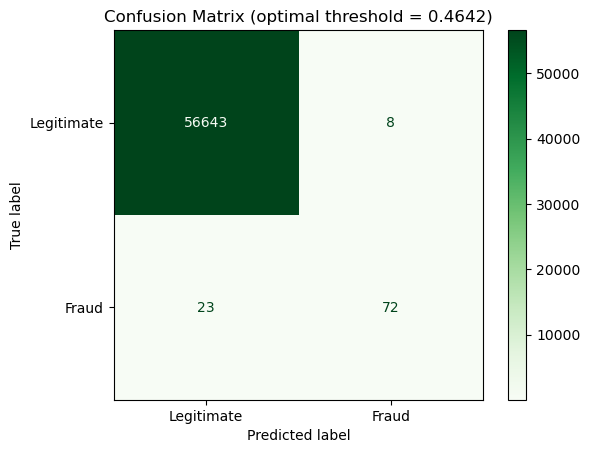

              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56651
       Fraud       0.90      0.76      0.82        95

    accuracy                           1.00     56746
   macro avg       0.95      0.88      0.91     56746
weighted avg       1.00      1.00      1.00     56746



In [24]:
y_pred_best = (y_prob > best_threshold).astype(int)

cm_best = confusion_matrix(y_test, y_pred_best)
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_best, display_labels=["Legitimate", "Fraud"])
disp2.plot(cmap="Greens")
plt.title(f"Confusion Matrix (optimal threshold = {best_threshold:.4f})")
plt.show()

print(classification_report(y_test, y_pred_best, target_names=["Legitimate", "Fraud"]))

In [25]:
!pip install streamlit

In [26]:
model.save('fraud_model.h5')

### END